In [1]:
from transformers import AutoModelForMaskedLM
from transformers import AutoTokenizer, AutoModelForCausalLM, AutoModel, AutoModelForSeq2SeqLM, AutoConfig
import torch
device = torch.device('cuda:0')

tokenizer = AutoTokenizer.from_pretrained('facebook/esm2_t6_8M_UR50D')
config = AutoConfig.from_pretrained('facebook/esm2_t6_8M_UR50D')
model = AutoModelForMaskedLM.from_pretrained('facebook/esm2_t6_8M_UR50D').to(device)
model.eval()
print("Loaded BERT Model")

/home/andrew/anaconda3/envs/gointerp/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded BERT Model


In [2]:
import pandas as pd
enzyme_df= pd.read_csv('../../data/enzyme_dataset_seq.csv')
enzyme_df= enzyme_df[~enzyme_df['Sequence'].isna()]
enzyme_go_terms = [gt.split("'")[1] for gt in enzyme_df['GOTerm']]
import json
train_path = "/home/andrew/cafa5_team/data/"
with open(f"{train_path}/cafa_dataset/go_terms.json", "r") as f:
    go_terms = json.load(f)
term_ind_map = {t:i for i, t in enumerate(go_terms)}
enzyme_df['GOTerm'] = enzyme_go_terms
enzyme_df= enzyme_df[enzyme_df['GOTerm'].isin(term_ind_map)]
enzyme_term_index = [term_ind_map[t] for t in enzyme_df['GOTerm']]
enzyme_df['GOTermIndex'] = enzyme_term_index
annotated_indices = [list(filter(lambda x: x < min(1024, len(seq)), map(int, x[1:-1].split(',')))) for x, seq in zip(enzyme_df['AnnotatedIndices'], enzyme_df['Sequence'])]
enzyme_df['AnnotatedIndices'] = annotated_indices

import transformers
tokenizer = transformers.AutoTokenizer.from_pretrained('facebook/esm2_t6_8M_UR50D')
def enzyme_iterator():
     for i, pid, annot_ind, enzyme_cls, goterm, seq, go_ind in enzyme_df.itertuples():
          # print(pid, annot_ind, enzyme_cls, goterm, seq, go_ind)
          inputs = tokenizer.batch_encode_plus([seq], add_special_tokens=True, padding='max_length',
                                             truncation=True, return_attention_mask=True, max_length=1024)
          yield {'prot_id': pid, 'annot_ind': annot_ind, 'go_ind': go_ind, 'seq': seq, 'seq_ind': inputs['input_ids'], 'mask': inputs['attention_mask']}

In [3]:
print(sum(len(x) > 0 for x in enzyme_df['AnnotatedIndices']))

778


In [6]:
r = next(iter(enzyme_iterator()))
bert_attribution_l = []
with torch.no_grad():
    seq_ind, mask =  torch.tensor(r['seq_ind']).to(device), torch.BoolTensor(r['mask']).to(device)
    residue_coverage = 6
    seq_batch, batch_inds, mut_inds = mask_seq(seq_ind[:, :], mask[:, :], tokenizer.mask_token_id, residue_coverage=residue_coverage)
    bert_pred = model(seq_batch, torch.tile(mask, (seq_batch.shape[0], 1)))
    mut_distr = torch.softmax(bert_pred.logits, dim=2)
    N, L, T = bert_pred.logits.shape
    bert_distr = torch.zeros(L, T, device=device)
    for bi, ti in zip(batch_inds.flatten(), mut_inds.flatten()):
        bert_distr[ti, :] += mut_distr[bi, ti, :]
    bert_distr /= residue_coverage
bert_distr = bert_distr.cpu()

In [5]:
def mask_seq(seq_ind, attention_mask, mask_token, residue_coverage=6, mut_per=0.15):
    device = seq_ind.device
    seq_len = attention_mask.sum()-1
    mut_count = torch.floor(seq_len*mut_per).int().item()
    total_muts = (torch.floor(seq_len*residue_coverage/mut_count)*mut_count).int().item()

    mut_inds = (torch.randperm(total_muts).reshape(-1, mut_count).to(device) % seq_len) + 1
    batch_inds = torch.tile(torch.arange(0, mut_inds.shape[0]).reshape((-1, 1)), (1, mut_count))
    mut_inds, batch_inds = mut_inds.to(device), batch_inds.to(device)

    batch = torch.tile(seq_ind, (mut_inds.shape[0], 1))
    batch[batch_inds, mut_inds] = mask_token
    return batch, batch_inds, mut_inds

In [8]:
bert_attribution_l = []
with torch.no_grad():
    for i, r in enumerate(enzyme_iterator()):
        seq_ind, mask =  torch.tensor(r['seq_ind']).to(device), torch.BoolTensor(r['mask']).to(device)
        residue_coverage = 6
        seq_batch, batch_inds, mut_inds = mask_seq(seq_ind[:, :], mask[:, :], tokenizer.mask_token_id, residue_coverage=residue_coverage)
        bert_pred = model(seq_batch, torch.tile(mask, (seq_batch.shape[0], 1)))
        mut_distr = torch.softmax(bert_pred.logits, dim=2)
        N, L, T = bert_pred.logits.shape
        bert_distr = torch.zeros(L, T, device=device)
        for bi, ti in zip(batch_inds.flatten(), mut_inds.flatten()):
            bert_distr[ti, :] += mut_distr[bi, ti, :]
        bert_distr /= residue_coverage
        seq_entropy = (-bert_distr*torch.log(bert_distr)).sum(dim=1)
        bert_attribution_l.append(seq_entropy.cpu())
        if(i % 10 == 0):
            print(i)

0
10
20
30
40
50
60
70
80
90
100
110
120
130
140
150
160
170
180
190
200
210
220
230
240
250
260
270
280
290
300
310
320
330
340
350
360
370
380
390
400
410
420
430
440
450
460
470
480
490
500
510
520
530
540
550
560
570
580
590
600
610
620
630
640
650
660
670
680
690
700
710
720
730
740
750
760
770
780


In [9]:
bert_attribution = torch.stack(bert_attribution_l)
bert_attribution = -torch.nan_to_num(bert_attribution, 0)

In [10]:
# attr_dict = {'attributions_ig': attributions_ig, 'attributions_lact': attributions_lact, 'attributions_lfa': attributions_lfa}
import pickle
with open('../../data/enzyme_attributions.pkl', 'rb') as f:
    attr_dict = pickle.load(f)

In [11]:
attributions_ig = attr_dict['attributions_ig']
sum_attributions_ig = attributions_ig.sum(dim=2)
magn_attributions_ig = attributions_ig.norm(dim=2)

attributions_lact = attr_dict['attributions_lact']
sum_attributions_lact = attributions_lact.sum(dim=2)
magn_attributions_lact = attributions_lact.norm(dim=2)

attributions_lfa = attr_dict['attributions_lfa']

attributions_bert = bert_attribution.to('cpu')
for attr in [sum_attributions_ig, magn_attributions_ig, sum_attributions_lact, magn_attributions_lact, attributions_lfa, attributions_bert]:
    attr /= torch.norm(attr)

In [12]:
for attr in [sum_attributions_ig, magn_attributions_ig, sum_attributions_lact, magn_attributions_lact, attributions_lfa, attributions_bert]:
    print(attr.device)

cpu
cpu
cpu
cpu
cpu
cpu


In [16]:
r = next(iter(enzyme_iterator()))
text = r['seq']
tokens, mask = torch.tensor(r['seq_ind']).to('cpu'), torch.BoolTensor(r['mask']).to('cpu')
print(r['annot_ind'])
from IPython.display import display, HTML
from captum.attr._utils.visualization import format_word_importances

true_importances = torch.zeros_like(tokens)
true_importances[0, r['annot_ind']] = 1
dom = format_word_importances(text[150:250], true_importances[151:251])
html = HTML("".join(dom))
display(html)

[162, 191, 217, 242, 266, 294]


In [ ]:
from IPython.display import display, HTML
from captum.attr._utils.visualization import format_word_importances
text = next(iter(enzyme_df['Sequence']))[:50]
inputs = tokenizer.batch_encode_plus([text], add_special_tokens=True, padding='max_length',
                                             truncation=True, return_attention_mask=True, max_length=1024)
tokens, mask =  torch.tensor(inputs['input_ids']).to(device), torch.BoolTensor(inputs['attention_mask']).to(device)
seq_batch, batch_inds, mut_inds = mask_seq(seq_ind[:, :51], mask[:, :51], tokenizer.mask_token_id, residue_coverage=residue_coverage)

dom = format_word_importances(text, torch.zeros(len(text)))
html = HTML("".join(dom))
display(html)

masking = -0.5*(seq_batch == tokenizer.mask_token_id).cpu()
dom = [format_word_importances(text, 0*masking[i]) for i in range(seq_batch.shape[0])]
html = HTML("".join(dom))
display(html)

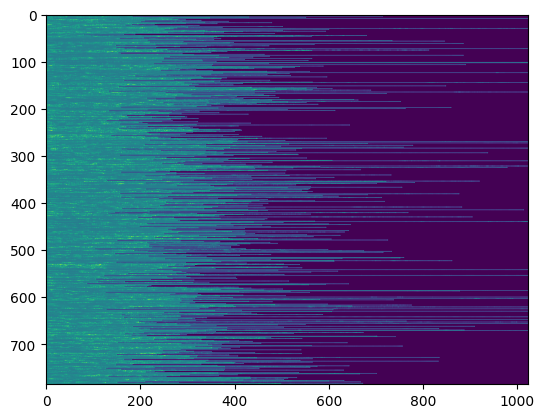

In [29]:
import matplotlib.pyplot as plt
plt.imshow(-bert_attribution)
plt.show()

In [17]:
def mean_reciprocal_rank(token_attribution, conserved_tokens):
    token_attribution =  token_attribution - 1e5*(token_attribution == 0) #Ignore padding
    attribution_argsort = torch.argsort(token_attribution, dim=1, descending=True)
    attribution_ranks = torch.argsort(attribution_argsort, dim=1, descending=False)
    ttr = 0
    tct = 0
    for i, token_ind in enumerate(conserved_tokens):
        token_ranks = attribution_ranks[i, token_ind]
        ttr += torch.divide(1, token_ranks+1).sum()
        tct += token_ranks.shape[0]
    return ttr / tct

def mean_percent_rank(token_attribution, seq_len, conserved_tokens):
    token_mask = torch.tile(torch.arange(0, 1024).reshape(1, -1), (token_attribution.shape[0], 1))
    token_mask[:, 0] += 1024
    token_mask = token_mask < seq_len.reshape(-1, 1)
    token_attribution =  token_attribution.clone() - 1e5*(~token_mask)
    attribution_argsort = torch.argsort(token_attribution, dim=1, descending=True)
    attribution_ranks = torch.argsort(attribution_argsort, dim=1, descending=False)
    attribution_percent_rank = attribution_ranks / seq_len.reshape(-1, 1)
    ttr = 0
    tct = 0
    for i, token_ind in enumerate(conserved_tokens):
        # print(token_ind)
        token_ranks = attribution_percent_rank[i, token_ind]
        # print(token_ranks)
        ttr += token_ranks.sum()
        tct += token_ranks.shape[0]
    return ttr / tct


mrr = mean_reciprocal_rank(-bert_attribution, enzyme_df['AnnotatedIndices'])
mpr = mean_percent_rank(-bert_attribution, torch.tensor([len(s) for s in enzyme_df['Sequence']]), list(enzyme_df['AnnotatedIndices']))
print(f'Mean-Reciprocal Rank {mrr}, Mean-Percentage Rank {mpr}')

Mean-Reciprocal Rank 0.05374598130583763, Mean-Percentage Rank 0.442494660615921


In [52]:
from IPython.display import display, HTML
from captum.attr._utils.visualization import format_word_importances
text = next(iter(enzyme_df['Sequence']))[:50]
inputs = tokenizer.batch_encode_plus([text], add_special_tokens=True, padding='max_length',
                                             truncation=True, return_attention_mask=True, max_length=1024)
tokens, mask =  torch.tensor(inputs['input_ids']).to(device), torch.BoolTensor(inputs['attention_mask']).to(device)
seq_batch, batch_inds, mut_inds = mask_seq(seq_ind[:, :51], mask[:, :51], tokenizer.mask_token_id, residue_coverage=residue_coverage)

dom = format_word_importances(text, torch.zeros(len(text)))
html = HTML("".join(dom))
display(html)

masking = -0.5*(seq_batch == tokenizer.mask_token_id).cpu()
dom = [format_word_importances(text, 0*masking[i]) for i in range(seq_batch.shape[0])]
html = HTML("".join(dom))
display(html)

In [36]:
print((seq_batch == tokenizer.mask_token_id).sum(dim=0))

tensor([0, 2, 2,  ..., 0, 0, 0], device='cuda:1')


In [24]:
print(seq_ind)


tensor([[ 0, 20, 15,  ...,  1,  1,  1]], device='cuda:1')


TypeError: reshape(): argument 'shape' failed to unpack the object at pos 2 with error "type must be tuple of ints,but got Tensor"